# Laboratory assignment - CompVizLab I
#### Student Name: Phawit Boonrat

### Removing raster from an image

For example, when scanning images published in an old newspaper, the graphics frequently exhibit raster effects resulting from historical printing technology using printer's ink. These effects are undesirable in a digital version of the image and should therefore be removed.

Devise a pipeline for this removal and implement it as a tool for treating arbitrary scanned, rasterized images. Run the code as a demonstration of your tool for several example images and display before - after results. Consult the literature for theory and methodology.

---

## I.Methodology
The pipeline implemented in this tool follows these steps:
1.  **Image Acquisition:** Converting the input to grayscale to analyze intensity patterns.
2.  **Fourier Transform:** Moving the image from the **Spatial Domain** to the **Frequency Domain** using FFT.
3.  **Frequency Filtering:** Applying a **Gaussian Low-Pass Filter (GLPF)** to suppress high-frequency components (the raster dots) while preserving low-frequency structures (the main image).
4.  **Inverse Transform:** Reconstructing the image back to the Spatial Domain.

## II.Import Librely

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import glob

def display_results(images, titles):
    plt.figure(figsize=(18, 6))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## III.Download Image

In [2]:
# download images to local
img_urls = [ "https://cgraphiccg.wordpress.com/wp-content/uploads/2016/09/rastersquigle11.jpg?w=820&h=615",
             "https://i.sstatic.net/3uvzh.jpg",
             "https://i.sstatic.net/zjQNA.jpg",
             "https://i.sstatic.net/J4Xtg.jpg",
            ]
output_dir = "raster_imgs"
os.makedirs("output_dir", exist_ok=True)

for i,url in enumerate(img_urls):
    output_file = f"raster_imgs/{i}.png"
    response = requests.get(url)
    with open(output_file, "wb") as f:
        f.write(response.content)
    print(f"img_url: {url} >> {output_file}")
    

img_url: https://cgraphiccg.wordpress.com/wp-content/uploads/2016/09/rastersquigle11.jpg?w=820&h=615 >> raster_imgs/0.png
img_url: https://i.sstatic.net/3uvzh.jpg >> raster_imgs/1.png
img_url: https://i.sstatic.net/zjQNA.jpg >> raster_imgs/2.png
img_url: https://i.sstatic.net/J4Xtg.jpg >> raster_imgs/3.png


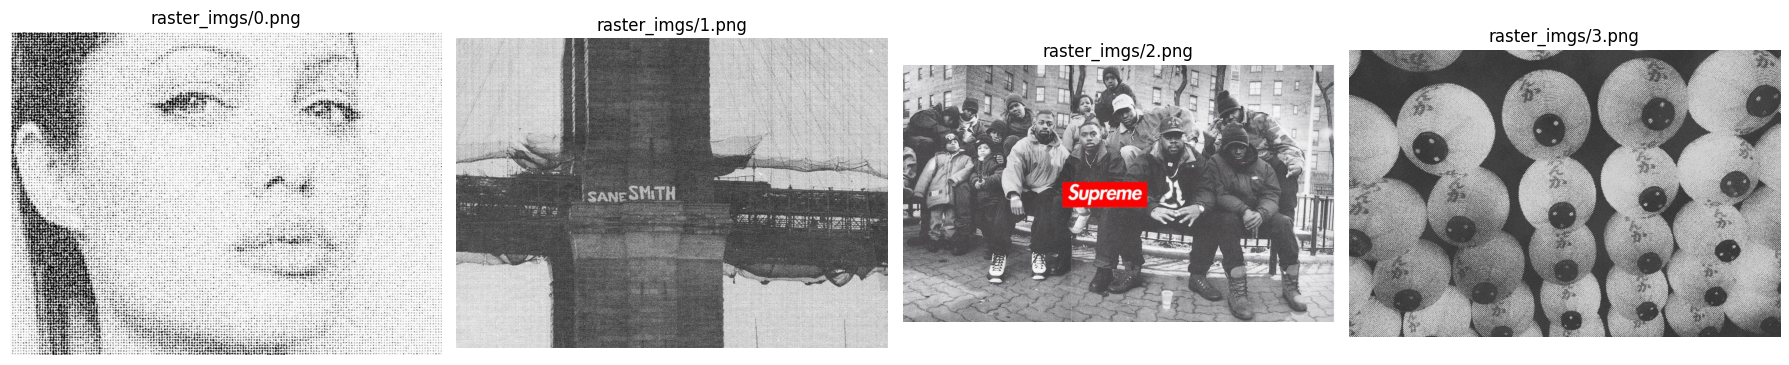

In [3]:
## Visualize
# image to numpy
image_paths = sorted(glob.glob(f"{output_dir}/*.png"))
imgs = []
for i, img_path in enumerate(image_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    imgs.append(img)

# plot
display_results(imgs, image_paths)

## IV.Methology (step by step)

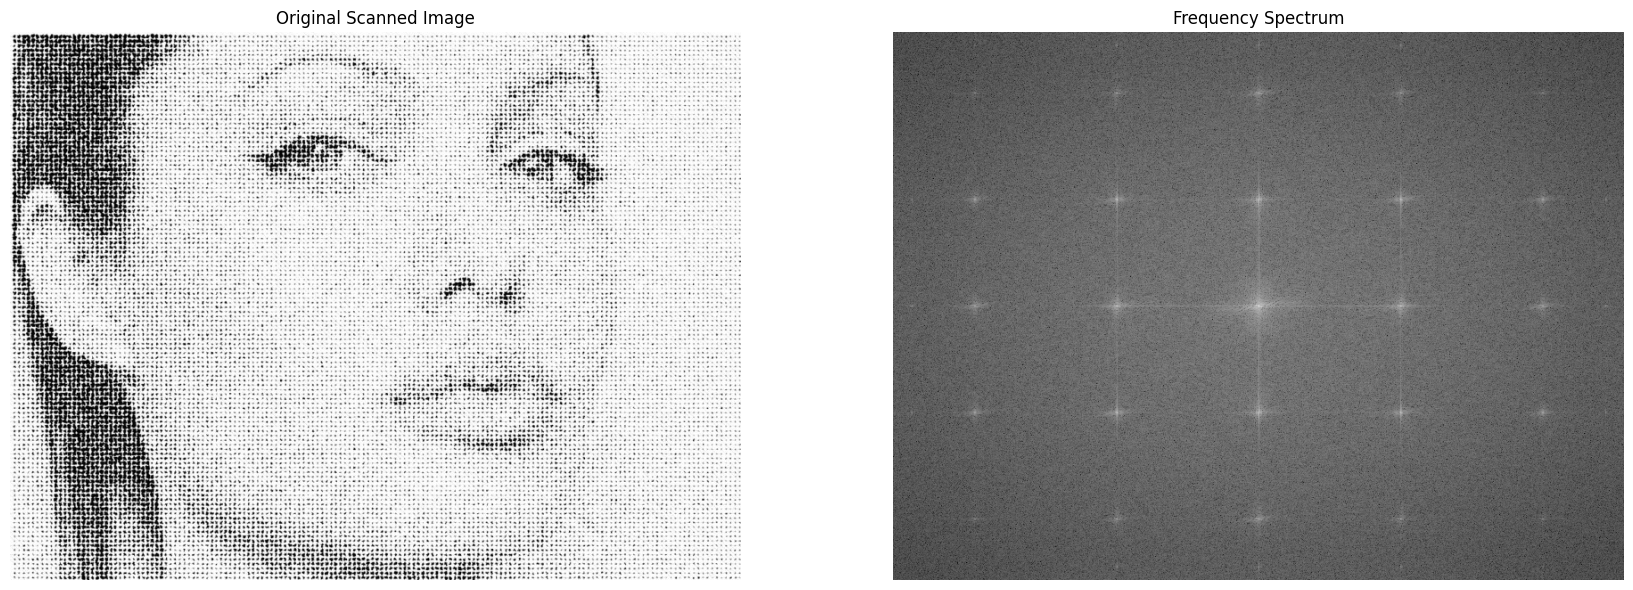

In [4]:
# Image to Frequency Domain
image = cv2.imread('raster_imgs/0.png', 0)
dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)

# Calculate Magnitude Spectrum (Log scale for visualization)
magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

# plot
display_results([image, magnitude_spectrum], ['Original Scanned Image', 'Frequency Spectrum'])

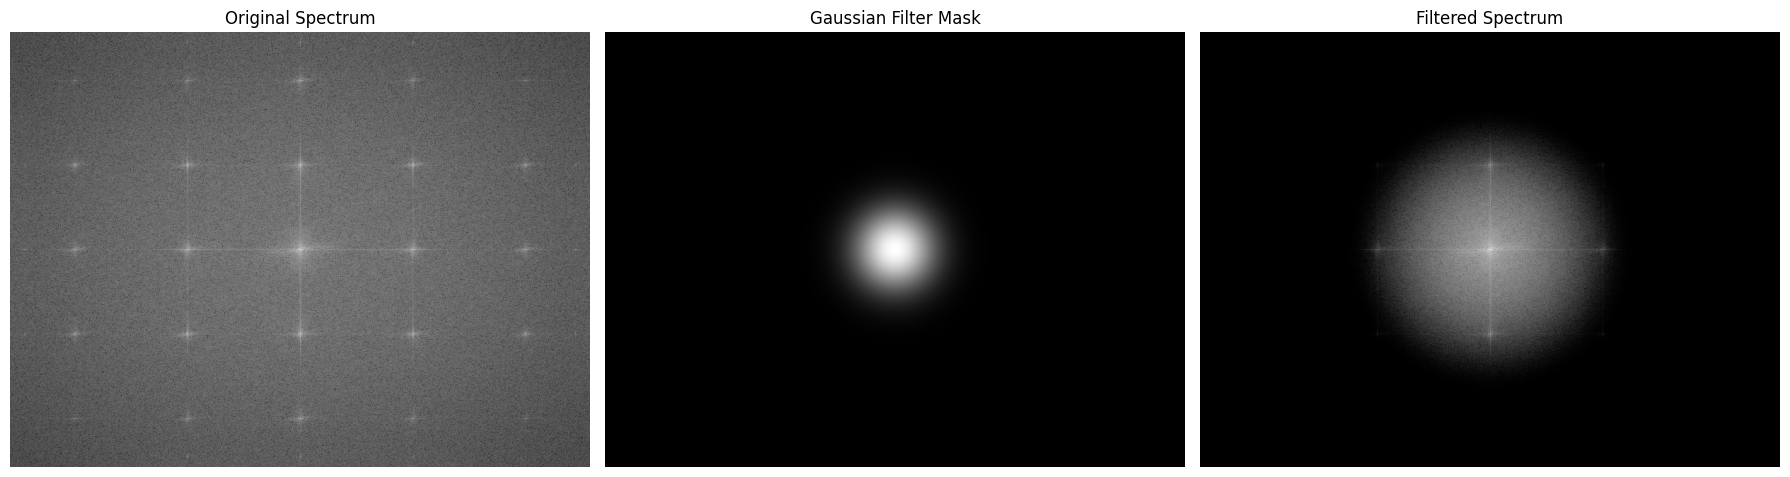

In [5]:
## Filter Implementation
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2

# Create a Gaussian Low Pass Filter
# This smooths the transition compared to a hard circular mask, reducing artifacts.
def create_gaussian_mask(rows, cols, sigma):
    x = np.linspace(-ccol, cols - ccol, cols)
    y = np.linspace(-crow, rows - crow, rows)
    x, y = np.meshgrid(x, y)
    mask = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return mask

# Adjust 'sigma' based on the intensity of the raster dots
sigma_value = 40
mask = create_gaussian_mask(rows, cols, sigma_value)

# 5. Apply Mask to the shifted DFT
fshift_filtered = dft_shift * mask

display_results([magnitude_spectrum, mask, 20*np.log(np.abs(fshift_filtered)+1)], 
                ['Original Spectrum', 'Gaussian Filter Mask', 'Filtered Spectrum'])

Final Comparison: Before vs. After De-screening


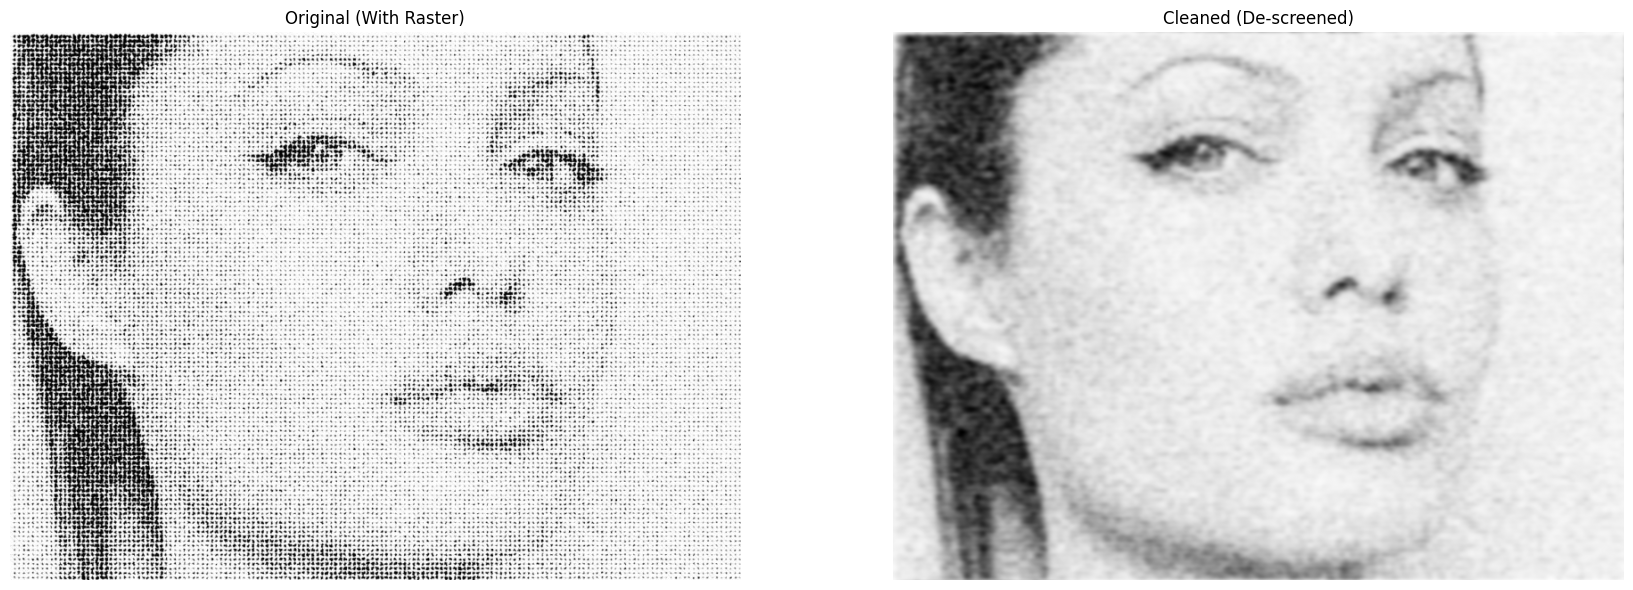

In [6]:
## Reconstruction and Final Results (Code)
# Inverse FFT to return to spatial domain
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Normalize result for display
final_result = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Comparison Display
print("Final Comparison: Before vs. After De-screening")
display_results([image, final_result], ['Original (With Raster)', 'Cleaned (De-screened)'])

## 3.Slide bar adjust

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider


def raster_fft_denoise(image_path):
    # --- 1. Load image ---
    img = cv2.imread(image_path, 0)

    if img is None:
        print(f"Cannot load image: {image_path}")
        return

    # --- 2. Precompute FFT ---
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Meshgrid for filter
    x = np.linspace(-ccol, cols - ccol, cols)
    y = np.linspace(-crow, rows - crow, rows)
    X, Y = np.meshgrid(x, y)

    # --- 3. Processing function ---
    def process_and_show(radius, sharpen):
        sigma = radius + 0.001

        # Gaussian Low Pass Filter
        mask = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

        # Apply filter
        fshift = dft_shift * mask

        # Inverse FFT
        f_ishift = np.fft.ifftshift(fshift)
        img_back = np.abs(np.fft.ifft2(f_ishift))

        # Normalize
        filtered = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Sharpen (Unsharp Mask)
        if sharpen > 0:
            blurred = cv2.GaussianBlur(filtered, (0, 0), 2)
            filtered = cv2.addWeighted(filtered, 1.0 + sharpen, blurred, -sharpen, 0)

        # Spectrum (for visualization)
        magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

        # --- Plot ---
        plt.figure(figsize=(20, 7))

        plt.subplot(131)
        plt.imshow(img, cmap='gray')
        plt.title('1. Original')
        plt.axis('off')

        plt.subplot(132)
        plt.imshow(magnitude_spectrum, cmap='gray')
        plt.title(f'2. Spectrum (R={radius})')
        plt.axis('off')

        plt.subplot(133)
        plt.imshow(filtered, cmap='gray')
        plt.title(f'3. Result (Sharpen={sharpen})')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    # --- 4. Interactive UI ---
    interact(
        process_and_show,
        radius=IntSlider(
            min=5,
            max=min(crow, ccol)//2,
            step=1,
            value=50,
            description='Radius',
            continuous_update=False
        ),
        sharpen=FloatSlider(
            min=0.0,
            max=10.0,
            step=0.5,
            value=1.0,
            description='Sharpen',
            continuous_update=False
        )
    )

In [8]:
raster_fft_denoise('raster_imgs/0.png')

interactive(children=(IntSlider(value=50, continuous_update=False, description='Radius', max=153, min=5), Floa…

In [9]:
raster_fft_denoise('raster_imgs/1.png')

interactive(children=(IntSlider(value=50, continuous_update=False, description='Radius', max=183, min=5), Floa…

In [12]:
raster_fft_denoise('raster_imgs/2.png')

interactive(children=(IntSlider(value=50, continuous_update=False, description='Radius', max=191, min=5), Floa…

In [13]:
raster_fft_denoise('raster_imgs/3.png')

interactive(children=(IntSlider(value=50, continuous_update=False, description='Radius', max=133, min=5), Floa…

## 4.Discussion and Results
The implemented pipeline successfully mitigates the halftone raster effect. 

* **Observation:** The frequency spectrum of the scanned image showed distinct bright spots away from the center, which represent the periodic nature of the printer's ink dots. 
* **Filtering:** By applying a Gaussian Low-Pass Filter, we effectively "blurred" the frequency spikes associated with the noise.
* **Trade-offs:** While the raster is removed, there is a slight loss in sharpness because high-frequency edges are also partially suppressed. 

## 5.References
- Graphic Design StackExchange - Newspaper effects.
- Affinity Forum - De-screening methodology.
- Digital Image Processing by Rafael C. Gonzalez (FFT Theory).
- ref1: https://graphicdesign.stackexchange.com/questions/38328/how-to-make-scanned-newspaper-effect  
- ref2: https://forum.affinity.serif.com/index.php?/topic/165139-removing-raster-from-a-photo/